In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler,MinMaxScaler
from sklearn.metrics import accuracy_score ,confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

In [2]:
def train_test_model(model,x_train,x_test,y_train,y_test):
    # Train model
    model.fit(x_train,y_train)
    # Acurracy of train data
    train_acc = accuracy_score(y_train,model.predict(x_train))
    print(f'\n Train accuracy_score = {train_acc * 100:.2f}% \n')

    # Test model
    y_predict = model.predict(x_test)
    test_acc = accuracy_score(y_test,y_predict)
    #Evaluate Model
    # Show accuracy_score and classification_report
    print(f'\n Test accuracy_score = {test_acc * 100:.2f}% \n')
    print(f'Test classification_report = \n {classification_report(y_test,y_predict)}')
    

In [3]:
data = pd.read_csv('/kaggle/input/titanic-dataset/Titanic-Dataset.csv')

In [4]:
data.shape

(891, 12)

In [5]:
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
data.describe().T # to transpoze matrix

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [8]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
data['Age'].value_counts()

Age
24.00    30
22.00    27
18.00    26
19.00    25
28.00    25
         ..
36.50     1
55.50     1
0.92      1
23.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [10]:
data['Age'].nunique()

88

<Axes: >

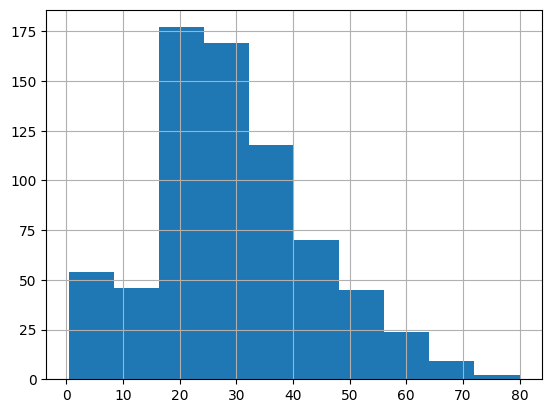

In [11]:
data['Age'].hist()

In [12]:
data['Age'].mean()

29.69911764705882

In [13]:
data['Age'].median()

28.0

In [14]:
data.groupby('Sex')['Age'].mean()

Sex
female    27.915709
male      30.726645
Name: Age, dtype: float64

In [15]:
data['Sex'][data['Age'].isnull()].value_counts()

Sex
male      124
female     53
Name: count, dtype: int64

In [16]:
# Value 30 depend on mean 29.6 and mean of males 30.7 and most nan records are males
data['Age'].fillna(30,inplace = True) 

<Axes: >

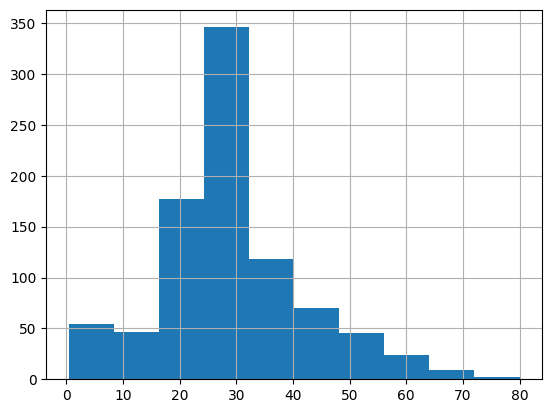

In [17]:
data['Age'].hist()

In [18]:
data['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [19]:
data['Embarked'].mode()[0] # index 0 to get value

'S'

In [20]:
data['Age'].fillna(data['Embarked'].mode()[0],inplace = True) 

In [21]:
data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

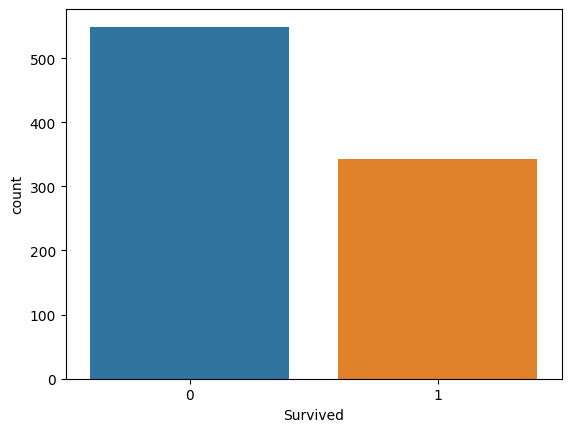

In [22]:
sns.countplot(x = 'Survived',data = data)

In [23]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [24]:
data.drop(['PassengerId', 'Name','Cabin','Ticket'],axis = 1,inplace = True)

<Axes: xlabel='Sex', ylabel='count'>

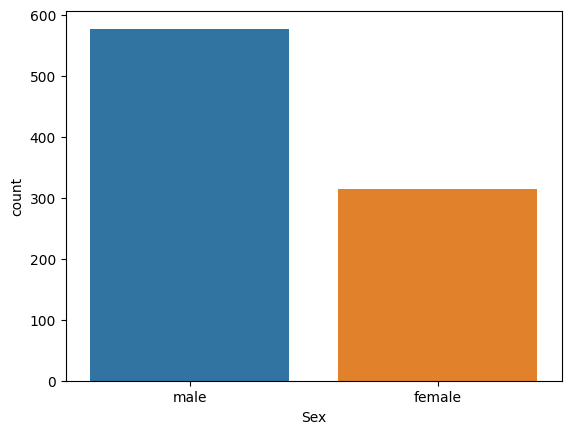

In [25]:
sns.countplot(x = 'Sex',data = data)

In [26]:
le = LabelEncoder()
data['Sex'] = le.fit_transform(data['Sex'])
le.classes_

array(['female', 'male'], dtype=object)

In [27]:
columns = pd.get_dummies(data['Embarked'])

In [28]:
data = pd.concat([data,columns],axis = 1)
data.drop(['Embarked'],axis = 1,inplace = True)

In [29]:
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,C,Q,S
0,0,3,1,22.0,1,0,7.2500,False,False,True
1,1,1,0,38.0,1,0,71.2833,True,False,False
2,1,3,0,26.0,0,0,7.9250,False,False,True
3,1,1,0,35.0,1,0,53.1000,False,False,True
4,0,3,1,35.0,0,0,8.0500,False,False,True
...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,False,False,True
887,1,1,0,19.0,0,0,30.0000,False,False,True
888,0,3,0,30.0,1,2,23.4500,False,False,True
889,1,1,1,26.0,0,0,30.0000,True,False,False


## Feature engineering

In [30]:
# SibSp No of siblings 
# Parch No of parents/children
# so i added them all in family
data['Familysize'] = data['SibSp'] + data['Parch']

In [31]:
data.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'C', 'Q',
       'S', 'Familysize'],
      dtype='object')

In [32]:
data.drop(['SibSp', 'Parch'],axis=1,inplace=True)

In [33]:
x = data.drop('Survived',axis=1)
y = data['Survived']

In [34]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [35]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [36]:
model = GaussianNB()
train_test_model(model,x_train_scaled,x_test_scaled,y_train,y_test)


 Train accuracy_score = 79.35% 


 Test accuracy_score = 79.33% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.83      0.81      0.82       105
           1       0.74      0.77      0.75        74

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179



In [37]:
model = LogisticRegression()
train_test_model(model,x_train_scaled,x_test_scaled,y_train,y_test)


 Train accuracy_score = 79.63% 


 Test accuracy_score = 80.45% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



In [38]:
model = SVC(kernel='rbf',C=2,gamma=0.3)
train_test_model(model,x_train_scaled,x_test_scaled,y_train,y_test)


 Train accuracy_score = 81.60% 


 Test accuracy_score = 79.33% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.78      0.90      0.84       105
           1       0.82      0.64      0.72        74

    accuracy                           0.79       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.79      0.79       179



In [39]:
model = KNeighborsClassifier(n_neighbors=21)
train_test_model(model,x_train_scaled,x_test_scaled,y_train,y_test)


 Train accuracy_score = 81.74% 


 Test accuracy_score = 78.77% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.78      0.90      0.83       105
           1       0.81      0.64      0.71        74

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.77       179
weighted avg       0.79      0.79      0.78       179



In [40]:
model = DecisionTreeClassifier(criterion='entropy',max_depth=5,random_state = 45)
train_test_model(model,x_train_scaled,x_test_scaled,y_train,y_test)


 Train accuracy_score = 84.83% 


 Test accuracy_score = 80.45% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.83      0.66      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.80      0.80       179



In [41]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=137,
    learning_rate=0.05,
    random_state=42
)
train_test_model(model,x_train_scaled,x_test_scaled,y_train,y_test)


 Train accuracy_score = 90.59% 


 Test accuracy_score = 82.12% 

Test classification_report = 
               precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

